# SPY / QQQ P/E 分位切点回测

**结论摘要**

- 当前 35 / 65 切点没有在 SPY 与 QQQ、6 与 12 个月四种组合中形成一致的收益排序。
- 40 / 60 的平均标准化分离度最高，但四种组合中也只有两种出现“低估收益高于高估”，不足以证明它更优。
- 五档极端区样本不足，且“极度高估”没有稳定对应更低收益或更深回撤。本轮保留 UI 的三档 35 / 65，不加入五档。

本分析使用每个时点之前的 5 年 P/E 计算滚动分位；信号形成后的下一个交易日才开始计算前瞻收益，避免未来数据进入标签。

## 数据与方法

- **P/E 月度历史**：2015-09-30 至 2026-09-15，SPY 与 QQQ 各 133 个观察点。
- **价格**：Yahoo Finance 供应商复权收盘价，2015-08-21 至 2026-09-15。
- **分位窗口**：过去 5 年，至少 60 个月历史；同值采用中位秩。
- **收益与回撤**：信号日后下一个交易日进入，在信号日后第 6 / 12 个日历月的首个交易日退出；区间最大回撤按复权价格路径计算。
- **不确定性**：连续月份的持有期互相重叠。置信区间按信号年份整块抽样；普通 Mann–Whitney p 值仅作为辅助，不视为独立样本检验。

数据来源：[World PE Ratio - S&P 500](https://worldperatio.com/index/sp-500/)、[World PE Ratio - Nasdaq 100](https://worldperatio.com/index/nasdaq-100/)、[Yahoo Finance SPY](https://finance.yahoo.com/quote/SPY/history/)、[Yahoo Finance QQQ](https://finance.yahoo.com/quote/QQQ/history/)。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from backtest_engine import AnalysisConfig, run

pd.set_option("display.max_columns", 30)
plt.style.use("dark_background")
COLORS = {"低估": "#65d6ad", "合理": "#d9bd67", "高估": "#eb877b",
          "极度低估": "#35c894", "极度高估": "#e66058"}
GROUP_EN = {"极度低估": "Extreme low", "低估": "Low", "合理": "Fair",
            "高估": "High", "极度高估": "Extreme high"}

RECOMPUTE = False  # Set True to rerun the 5,000-draw year-block bootstrap.
output_names = ["data_quality", "signals", "current_rule_summary", "current_rule_tests",
                "grid_search", "grid_ranking", "five_band_summary", "extreme_tests"]
results = run(AnalysisConfig()) if RECOMPUTE else {
    name: pd.read_csv(Path("outputs") / f"{name}.csv") for name in output_names
}
manifest = json.loads((Path("inputs") / "source_manifest.json").read_text(encoding="utf-8"))
display(results["data_quality"])
print("输入哈希：", manifest["pe"]["sha256"][:12], manifest["prices"]["sha256"][:12])

,dataset,rows,first,last,duplicate_dates,missing_values,covered_months,expected_months
0,SPY P/E（月度）,133,2015-09-30,2026-09-15,0,0,133,133
1,SPY 复权收盘价（日度）,2782,2015-08-21,2026-09-15,0,0,134,134
2,QQQ P/E（月度）,133,2015-09-30,2026-09-15,0,0,133,133
3,QQQ 复权收盘价（日度）,2782,2015-08-21,2026-09-15,0,0,134,134


输入哈希： d5408d328feb cc9af19516fb


## 1. 当前 35 / 65 切点

表中的收益和最大回撤均为样本均值。最大回撤越接近 0，区间下跌越浅。

,标的,周期（月）,分档,样本数,平均收益%,中位收益%,收益P25%,收益P75%,正收益率%,平均最大回撤%
0,QQQ,6,低估,4,11.7,6.0,-4.1,21.9,50.0,-15.5
1,QQQ,6,合理,10,9.2,14.8,-5.0,19.6,60.0,-13.9
2,QQQ,6,高估,53,8.7,10.5,5.9,16.4,81.1,-13.2
3,QQQ,12,低估,4,33.2,32.4,27.6,38.0,100.0,-16.3
4,QQQ,12,合理,10,25.1,27.8,23.1,35.7,90.0,-16.0
5,QQQ,12,高估,47,15.0,23.0,6.9,29.1,76.6,-19.3
6,SPY,6,低估,5,2.9,1.2,0.4,4.0,80.0,-13.0
7,SPY,6,合理,10,4.7,7.9,-4.0,12.8,70.0,-11.1
8,SPY,6,高估,52,8.9,10.2,6.3,14.8,82.7,-9.1
9,SPY,12,低估,5,11.9,13.3,10.5,13.8,100.0,-14.0


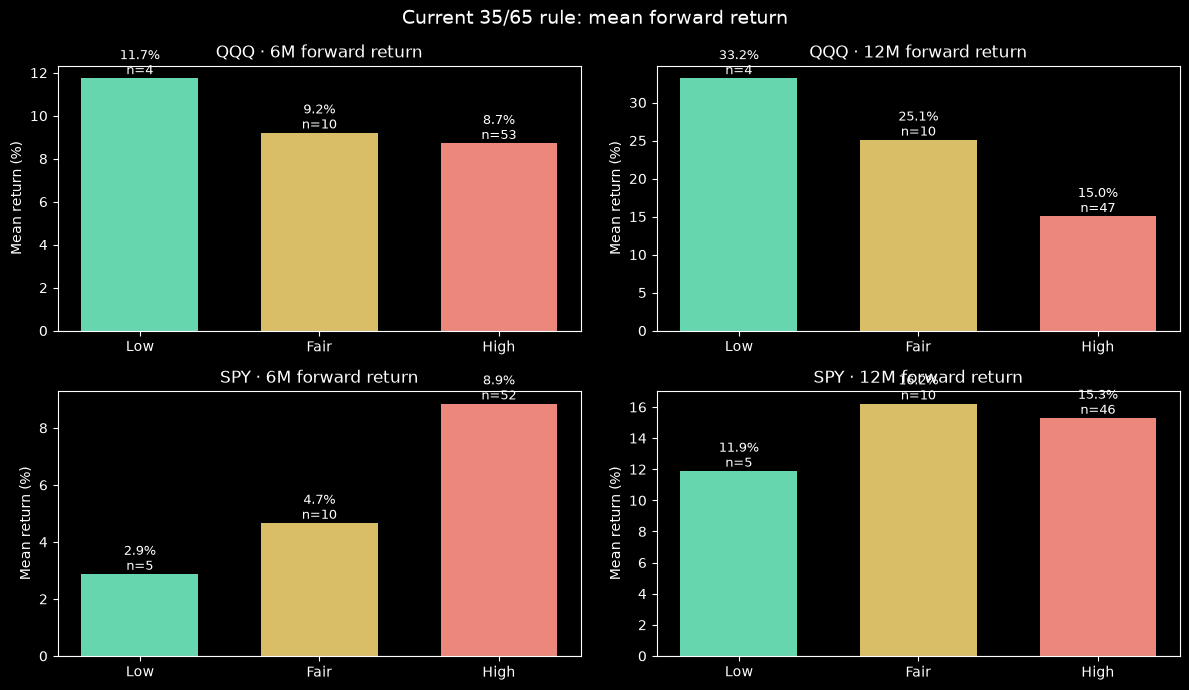

In [2]:
current = results["current_rule_summary"].copy()
view = current[["ticker", "horizon_months", "group", "n", "return_mean", "return_median",
                "return_p25", "return_p75", "positive_rate", "max_drawdown_mean"]].copy()
for column in ["return_mean", "return_median", "return_p25", "return_p75", "positive_rate", "max_drawdown_mean"]:
    view[column] = (view[column] * 100).round(1)
view.columns = ["标的", "周期（月）", "分档", "样本数", "平均收益%", "中位收益%", "收益P25%", "收益P75%", "正收益率%", "平均最大回撤%"]
display(view)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
for ax, ((ticker, horizon), sample) in zip(axes.flat, current.groupby(["ticker", "horizon_months"], sort=True)):
    sample = sample.set_index("group").reindex(["低估", "合理", "高估"]).dropna(subset=["return_mean"])
    ax.bar([GROUP_EN[str(x)] for x in sample.index], sample.return_mean * 100,
           color=[COLORS[str(x)] for x in sample.index], width=.65)
    for i, (_, row) in enumerate(sample.iterrows()):
        ax.text(i, row.return_mean * 100, f"{row.return_mean:.1%}\nn={int(row.n)}", ha="center", va="bottom", fontsize=9)
    ax.axhline(0, color="#81968d", lw=.8)
    ax.set_title(f"{ticker} · {horizon}M forward return")
    ax.set_ylabel("Mean return (%)")
fig.suptitle("Current 35/65 rule: mean forward return", fontsize=14)
fig.tight_layout()
plt.show()

In [3]:
tests = results["current_rule_tests"]
returns_test = tests[tests.metric == "forward_return"].copy()
for column in ["difference", "ci_low", "ci_high"]:
    returns_test[column] = (returns_test[column] * 100).round(1)
returns_test = returns_test[["ticker", "horizon_months", "low_n", "high_n", "difference", "ci_low", "ci_high", "mann_whitney_p_naive"]]
returns_test.columns = ["标的", "周期（月）", "低估n", "高估n", "低估−高估（百分点）", "年份块95%CI下限", "年份块95%CI上限", "普通p值（辅助）"]
display(returns_test.round(3))

,标的,周期（月）,低估n,高估n,低估−高估（百分点）,年份块95%CI下限,年份块95%CI上限,普通p值（辅助）
0,QQQ,6,4,53,3.0,-1.1,9.6,0.988
3,QQQ,12,4,47,18.1,5.0,34.9,0.097
6,SPY,6,5,52,-6.0,-9.4,-2.4,0.051
9,SPY,12,5,46,-3.4,-13.7,7.5,0.164


**读法**：如果切点有效，“低估 − 高估”应稳定为正。QQQ 12 个月为 +18.1 个百分点，但 SPY 6 / 12 个月分别为 -6.0 / -3.4 个百分点。四种组合中只有两种方向正确，且低估组只有 4–5 个重叠月度点，证据不足。

## 2. 候选切点网格搜索

“方向正确数”统计四个比较（SPY/QQQ × 6/12 个月）里低估组平均收益高于高估组的次数。“最小尾部样本数”取四个比较中低估/高估两端最小值。

,低切点,高切点,综合排名,四组合平均收益差（百分点）,平均标准化分离度,最小尾部样本数,方向正确数/4
0,40,60,1,2.26,0.081,6,2
1,35,65,2,2.94,0.044,4,2
2,30,70,3,2.15,-0.029,4,2
3,25,75,4,-2.74,-0.611,1,1
4,20,80,5,-4.91,-0.569,0,0


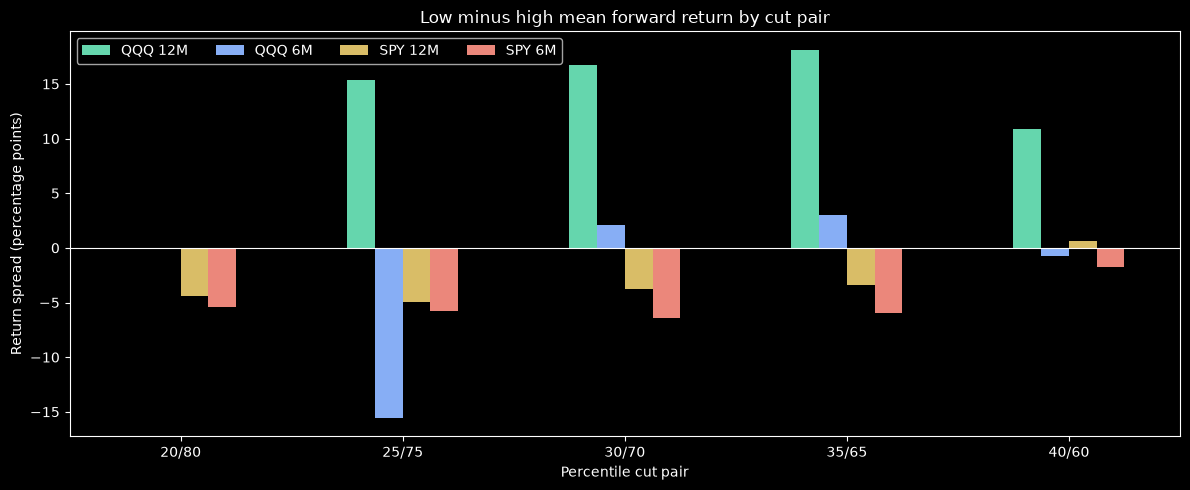

In [4]:
ranking = results["grid_ranking"].copy()
ranking["average_spread"] = (ranking.average_spread * 100).round(2)
ranking["average_standardized_spread"] = ranking.average_standardized_spread.round(3)
ranking.columns = ["低切点", "高切点", "综合排名", "四组合平均收益差（百分点）", "平均标准化分离度", "最小尾部样本数", "方向正确数/4"]
display(ranking)

detail = results["grid_search"].copy()
detail["cuts"] = detail.low_cut.astype(str) + "/" + detail.high_cut.astype(str)
detail["scenario"] = detail.ticker + " " + detail.horizon_months.astype(str) + "M"
pivot = detail.pivot(index="cuts", columns="scenario", values="mean_spread") * 100
pivot = pivot.reindex(["20/80", "25/75", "30/70", "35/65", "40/60"])
ax = pivot.plot(kind="bar", figsize=(12, 5), color=["#65d6ad", "#87aef5", "#d9bd67", "#eb877b"])
ax.axhline(0, color="white", lw=.8)
ax.set_title("Low minus high mean forward return by cut pair")
ax.set_xlabel("Percentile cut pair")
ax.set_ylabel("Return spread (percentage points)")
ax.legend(ncol=4, loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

40 / 60 在平均标准化分离度和最小尾部样本数上最好，但方向正确数仍只有 2 / 4。20 / 80 与 25 / 75 甚至出现空组或单个样本。网格搜索没有找到跨标的、跨周期都可靠的新切点，所以不应仅凭综合排名把 UI 改成 40 / 60。

## 3. 五档极端区

五档定义为 `<10% 极度低估`、`10–35% 低估`、`35–65% 合理`、`65–90% 高估`、`>90% 极度高估`。

,标的,周期（月）,分档,样本数,平均收益%,中位收益%,平均最大回撤%
0,QQQ,6,低估,4,11.7,6.0,-15.5
1,QQQ,6,合理,10,9.2,14.8,-13.9
2,QQQ,6,高估,35,7.6,10.8,-12.9
3,QQQ,6,极度高估,18,10.9,10.2,-13.7
4,QQQ,12,低估,4,33.2,32.4,-16.3
5,QQQ,12,合理,10,25.1,27.8,-16.0
6,QQQ,12,高估,31,10.3,16.2,-20.3
7,QQQ,12,极度高估,16,24.2,24.3,-17.5
8,SPY,6,极度低估,3,4.3,4.0,-10.6
9,SPY,6,低估,2,0.8,0.8,-16.7


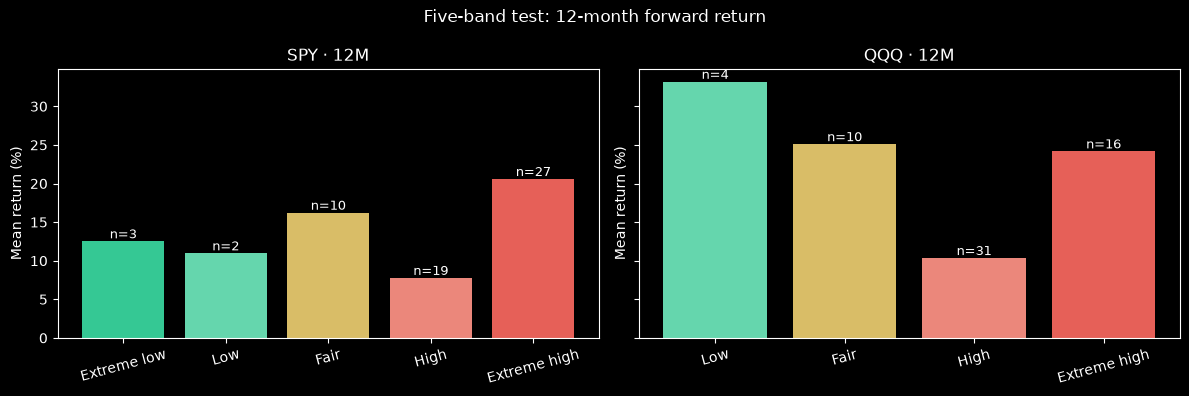

In [5]:
five = results["five_band_summary"].copy()
five_view = five[["ticker", "horizon_months", "group", "n", "return_mean", "return_median", "max_drawdown_mean"]].copy()
for column in ["return_mean", "return_median", "max_drawdown_mean"]:
    five_view[column] = (five_view[column] * 100).round(1)
five_view.columns = ["标的", "周期（月）", "分档", "样本数", "平均收益%", "中位收益%", "平均最大回撤%"]
display(five_view)

order = ["极度低估", "低估", "合理", "高估", "极度高估"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, ticker in zip(axes, ["SPY", "QQQ"]):
    sample = five[(five.ticker == ticker) & (five.horizon_months == 12)].set_index("group").reindex(order)
    sample = sample.dropna(subset=["return_mean"])
    ax.bar(range(len(sample)), sample.return_mean * 100,
           color=[COLORS.get(str(x), "#d9bd67") for x in sample.index])
    ax.set_xticks(range(len(sample)), [GROUP_EN[str(x)] for x in sample.index], rotation=15)
    for i, (_, row) in enumerate(sample.iterrows()):
        ax.text(i, row.return_mean * 100, f"n={int(row.n)}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{ticker} · 12M")
    ax.set_ylabel("Mean return (%)")
fig.suptitle("Five-band test: 12-month forward return")
fig.tight_layout()
plt.show()

## 决策

1. **保留 35 / 65 三档**。当前样本不能证明它有稳定预测力，但也没有候选切点形成明显、更可靠的替代。
2. **不增加五档 UI**。QQQ 的极度低估样本为 0，SPY 仅 2–3 个；极度高估组反而在多个组合中取得更高收益，方向与预期不一致。
3. **把这些标签当作“历史位置描述”**，不要把它们展示成经过充分验证的择时信号。
4. **下一次复核条件**：获得至少 15–20 年、口径一致的指数或 ETF P/E 历史后，采用走步样本外检验，再决定是否调整切点。

### 主要限制

- 5 年滚动窗口使可回测信号始于 2020 年，只覆盖 6–7 个自然年份。
- 月度信号的 6 / 12 个月收益区间大量重叠，表内样本数高于真正独立的市场周期数。
- P/E 数据源没有确认盈利口径，不能把该字段严格声称为 TTM P/E。
- 本轮网格搜索属于同一样本内比较，最高排名可能含有过拟合；因此没有直接据此修改产品阈值。